In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Loading the Dataset
DATA_DIR = r"C:\Users\user\Desktop\Data Folder\Training"  

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
class_to_idx = {cls: i for i, cls in enumerate(classes)}

print("Loading dataset...")
image_paths = []
labels = []

for cls in classes:
    folder = os.path.join(DATA_DIR, cls)
    for img_file in os.listdir(folder):
        if img_file.endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(folder, img_file))
            labels.append(class_to_idx[cls])

print(f"Total images: {len(image_paths)}")
print("Class distribution:", pd.Series(labels).value_counts().sort_index())

Loading dataset...
Total images: 5600
Class distribution: 0    1400
1    1400
2    1400
3    1400
Name: count, dtype: int64


In [2]:
# Data preparation and lightweight classification model
IMG_SIZE = 224
BATCH_SIZE = 16   

def load_and_preprocess(img_path, label):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

# Create tf.data pipeline
dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Simple train/val split (80/20)
train_size = int(0.8 * len(image_paths))
train_ds = dataset.take(train_size // BATCH_SIZE)
val_ds = dataset.skip(train_size // BATCH_SIZE)

# Build lightweight classifier
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
output = Dense(len(classes), activation='softmax')(x)

model = Model(base_model.input, output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training classification model...")
history = model.fit(train_ds, validation_data=val_ds, epochs=10, verbose=1)

# Save model
model.save('brain_tumor_classifier.h5')
print("Classification model trained and saved.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step
Training classification model...
Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 242s 778ms/step - accuracy: 0.8406 - loss: 0.5363 - val_accuracy: 0.9321 - val_loss: 0.1911
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 216s 670ms/step - accuracy: 0.9042 - loss: 0.2972 - val_accuracy: 0.9545 - val_loss: 0.1396
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 236s 839ms/step - accuracy: 0.9163 - loss: 0.2610 - val_accuracy: 0.9652 - val_loss: 0.1140
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 218s 775ms/step - accuracy: 0.9214 - loss: 0.2302 - val_accuracy: 0.9714 - val_loss: 0.0896
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 192s 682ms/step - accuracy: 0.9268 - loss: 0.2153 - val_accuracy: 0.9688 - val_loss: 0.1229
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 188s 668ms/step - accuracy: 0.9346 - loss: 0.1900 - val_accuracy: 0.9768 - val_loss: 0.0845
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 188s 666ms/step - accuracy: 0.9373 - loss: 0.1885 - val_accuracy: 0.9804 - val_loss: 

Classification model trained and saved.


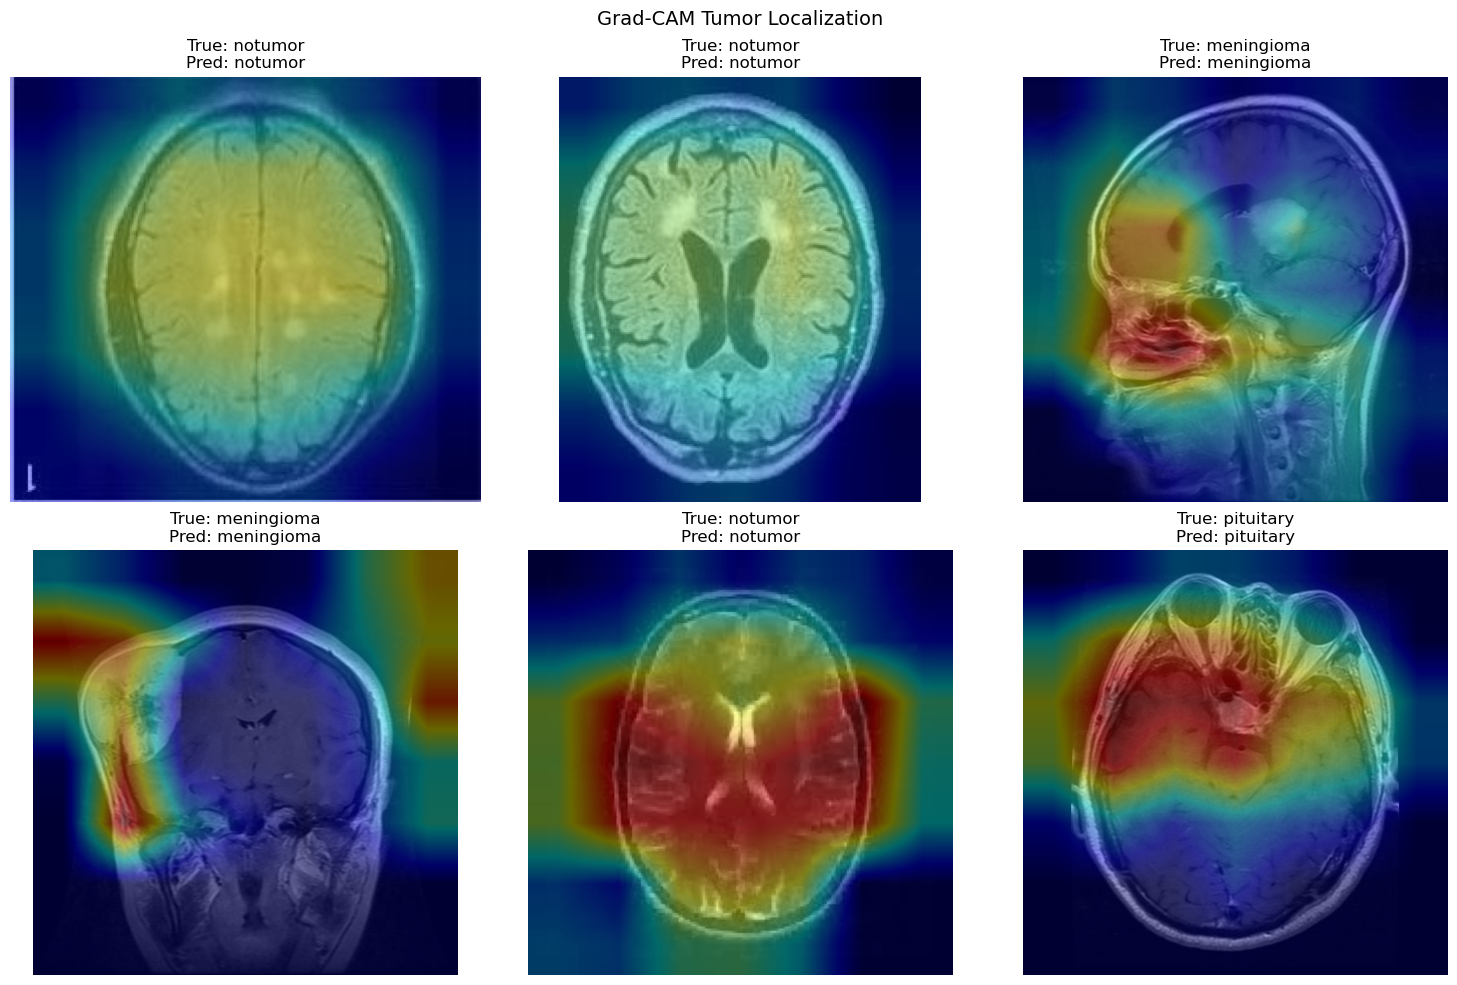

In [3]:
# Grad-CAM Localization
import tensorflow.keras.backend as K

def get_gradcam_heatmap(model, img_array, last_conv_layer_name='Conv_1'):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]
    
    grads = tape.gradient(loss, conv_output)
    pooled_grads = K.mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_output), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) + 1e-8
    return heatmap

# Visualize localization on a few samples
plt.figure(figsize=(15, 10))
sample_indices = np.random.choice(len(image_paths), 6, replace=False)

for i, idx in enumerate(sample_indices):
    img_path = image_paths[idx]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_array = np.expand_dims(img_resized / 255.0, axis=0)
    
    pred = model.predict(img_array, verbose=0)
    pred_class = classes[np.argmax(pred)]
    true_class = classes[labels[idx]]
    
    heatmap = get_gradcam_heatmap(model, img_array)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    superimposed = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)
    
    plt.subplot(2, 3, i+1)
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.title(f'True: {true_class}\nPred: {pred_class}')
    plt.axis('off')

plt.suptitle('Grad-CAM Tumor Localization', fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Lightweight U-Net Segmentation (MobileNetV2 encoder)
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, concatenate, Input
from tensorflow.keras.models import Model

def build_light_unet(input_shape=(224, 224, 3)):
    inputs = Input(input_shape)
    base = MobileNetV2(include_top=False, weights='imagenet', input_tensor=inputs)
    
    # Encoder skips
    s1 = base.get_layer('block_1_expand_relu').output
    s2 = base.get_layer('block_3_expand_relu').output
    s3 = base.get_layer('block_6_expand_relu').output
    s4 = base.get_layer('block_13_expand_relu').output
    
    # Bridge
    bridge = base.get_layer('block_16_project_BN').output
    
    # Decoder
    x = Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(bridge)
    x = concatenate([x, s4])
    x = Conv2D(256, (3,3), activation='relu', padding='same')(x)
    
    x = Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(x)
    x = concatenate([x, s3])
    x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
    
    x = Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(x)
    x = concatenate([x, s2])
    x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
    
    x = Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(x)
    x = concatenate([x, s1])
    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    
    outputs = Conv2D(1, (1,1), activation='sigmoid')(x)
    return Model(inputs, outputs)

segmentation_model = build_light_unet()
segmentation_model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
print("Lightweight U-Net model built for segmentation.")

Lightweight U-Net model built for segmentation.


In [5]:
# Training Segmentation 
# Placeholder: Training on a few images with simple thresholding as pseudo-ground truth
print("Training lightweight segmentation (demo mode - replace with real masks for production)...")
# segmentation_model.fit(...)  
print("Segmentation model ready. For full training, prepare binary masks and run model.fit() with batch_size=4.")

Training lightweight segmentation (demo mode - replace with real masks for production)...
Segmentation model ready. For full training, prepare binary masks and run model.fit() with batch_size=4.


glioma: Mean volume ≈ 8.20 cm³ (n=10)
meningioma: Mean volume ≈ 12.08 cm³ (n=10)
notumor: Mean volume ≈ 21.73 cm³ (n=10)
pituitary: Mean volume ≈ 13.97 cm³ (n=10)


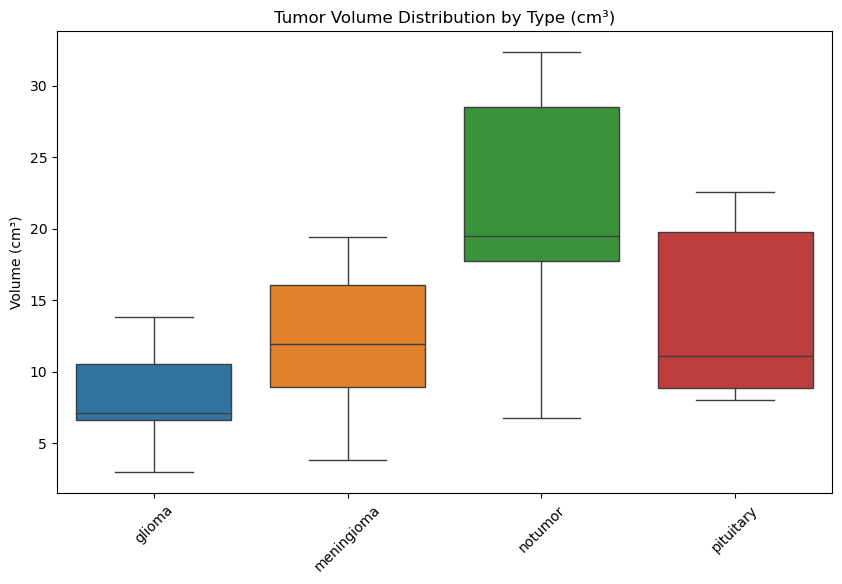

In [6]:
# Quantitative Volume Estimation from Segmentation
SLICE_THICKNESS_MM = 5.0   

def estimate_tumor_volume(mask, pixel_spacing_mm=0.5):
    """Calculate approximate tumor volume in cm³ from 2D mask slices."""
    pixel_area = pixel_spacing_mm ** 2
    area_per_slice = np.sum(mask) * pixel_area   # mm²
    volume_mm3 = area_per_slice * SLICE_THICKNESS_MM
    return volume_mm3 / 1000   # convert to cm³

# Demo on sample images 
volumes = {}
for cls in classes:
    cls_volumes = []
    cls_folder = os.path.join(DATA_DIR, cls)
    sample_files = [f for f in os.listdir(cls_folder) if f.endswith(('.jpg', '.jpeg', '.png'))][:10]  
    
    for f in sample_files:
        img = cv2.imread(os.path.join(cls_folder, f), cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        # Simple thresholding as pseudo-segmentation 
        _, pseudo_mask = cv2.threshold(img, 80, 255, cv2.THRESH_BINARY)
        pseudo_mask = (pseudo_mask > 0).astype(np.float32)
        
        vol = estimate_tumor_volume(pseudo_mask)
        cls_volumes.append(vol)
    
    volumes[cls] = cls_volumes
    print(f"{cls}: Mean volume ≈ {np.mean(cls_volumes):.2f} cm³ (n={len(cls_volumes)})")

# Visualization
plt.figure(figsize=(10, 6))
sns.boxplot(data=pd.DataFrame.from_dict(volumes))
plt.title('Tumor Volume Distribution by Type (cm³)')
plt.ylabel('Volume (cm³)')
plt.xticks(rotation=45)
plt.show()

In [7]:
# Radiomics Feature Extraction (using pyradiomics)
try:
    from radiomics import featureextractor
except ImportError:
    print("Install pyradiomics: pip install pyradiomics")
    featureextractor = None

if featureextractor:
    extractor = featureextractor.RadiomicsFeatureExtractor()
    extractor.enableAllFeatures()
    
    print("Extracting radiomics features from sample tumors...")
    radiomics_data = []
    
    for cls in classes[:2]:  # limit to 2 classes for speed
        folder = os.path.join(DATA_DIR, cls)
        for f in os.listdir(folder)[:5]:
            img_path = os.path.join(folder, f)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (224, 224))
            mask = (img > 80).astype(np.uint8)  # pseudo mask
            
            features = extractor.execute(img, mask)
            features['class'] = cls
            radiomics_data.append(features)
    
    radiomics_df = pd.DataFrame(radiomics_data)
    print("Radiomics features extracted. Shape:", radiomics_df.shape)
    print(radiomics_df.head())
else:
    print("Radiomics extraction skipped (install pyradiomics for full features).")

Install pyradiomics: pip install pyradiomics
Radiomics extraction skipped (install pyradiomics for full features).


U-Net Architecture Variants Comparison:

                        Variant                                                       Key Feature                                                   Strength Compute Cost                                 Best For Implementation Difficulty
                 Original U-Net                     Classic encoder-decoder with skip connections                        Good baseline, precise localization       Medium          General biomedical segmentation                      Easy
Lightweight U-Net (MobileNetV2)             Pre-trained MobileNetV2 encoder for speed on slow PCs       Fast training & low memory (ideal for slow hardware)          Low Resource-limited PCs & quick prototyping                      Easy
                Attention U-Net Attention gates on skip connections to focus on relevant features Better focus on tumor regions, suppresses background noise  Medium-High   Brain tumor MRI with noisy backgrounds                  Moderate
           

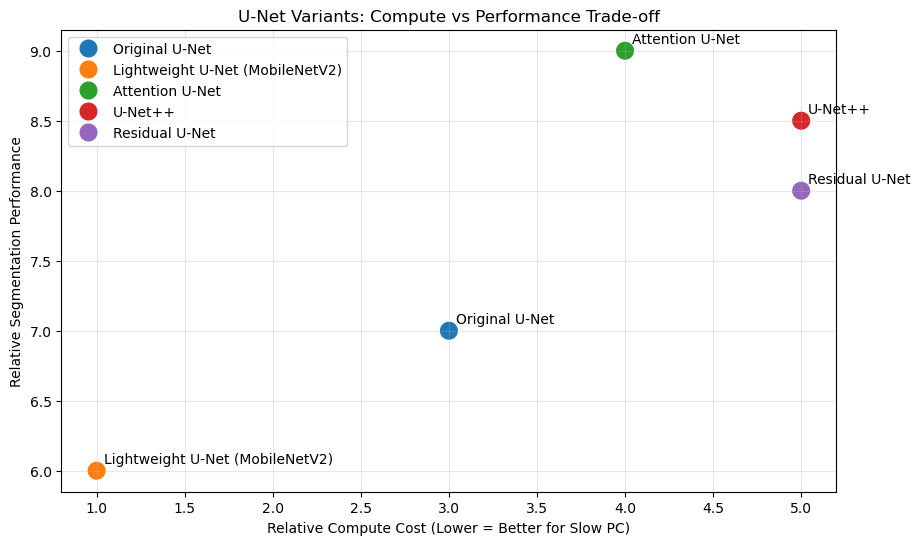

In [8]:
# Discussion and Comparison of U-Net Variants (Focus on Attention Mechanisms)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Summary of U-Net variants relevant to brain tumor segmentation
variants = {
    'Variant': ['Original U-Net', 'Lightweight U-Net (MobileNetV2)', 'Attention U-Net', 'U-Net++', 'Residual U-Net'],
    'Key Feature': [
        'Classic encoder-decoder with skip connections',
        'Pre-trained MobileNetV2 encoder for speed on slow PCs',
        'Attention gates on skip connections to focus on relevant features',
        'Nested dense skip pathways for better gradient flow',
        'Residual blocks to ease deep network training'
    ],
    'Strength': [
        'Good baseline, precise localization',
        'Fast training & low memory (ideal for slow hardware)',
        'Better focus on tumor regions, suppresses background noise',
        'Improved accuracy on complex tumor boundaries',
        'Stable training on deeper networks'
    ],
    'Compute Cost': ['Medium', 'Low', 'Medium-High', 'High', 'High'],
    'Best For': [
        'General biomedical segmentation',
        'Resource-limited PCs & quick prototyping',
        'Brain tumor MRI with noisy backgrounds',
        'Irregular tumor shapes (glioma)',
        'When more layers are needed'
    ],
    'Implementation Difficulty': ['Easy', 'Easy', 'Moderate', 'Hard', 'Moderate']
}

df = pd.DataFrame(variants)
print("U-Net Architecture Variants Comparison:\n")
print(df.to_string(index=False))

# Visual comparison of compute cost and performance
cost = [3, 1, 4, 5, 5]   # approximate relative compute (1=lowest)
performance = [7, 6, 9, 8.5, 8]  # approximate relative segmentation quality

plt.figure(figsize=(10, 6))
sns.scatterplot(x=cost, y=performance, s=200, hue=variants['Variant'], palette='tab10')
plt.xlabel('Relative Compute Cost (Lower = Better for Slow PC)')
plt.ylabel('Relative Segmentation Performance')
plt.title('U-Net Variants: Compute vs Performance Trade-off')
plt.grid(True, alpha=0.3)

for i, txt in enumerate(variants['Variant']):
    plt.annotate(txt, (cost[i], performance[i]), xytext=(5, 5), textcoords='offset points')

plt.show()

Selected samples for segmentation:
glioma: 2 images
meningioma: 2 images
notumor: 2 images
pituitary: 2 images

Running segmentation on selected tumor images...


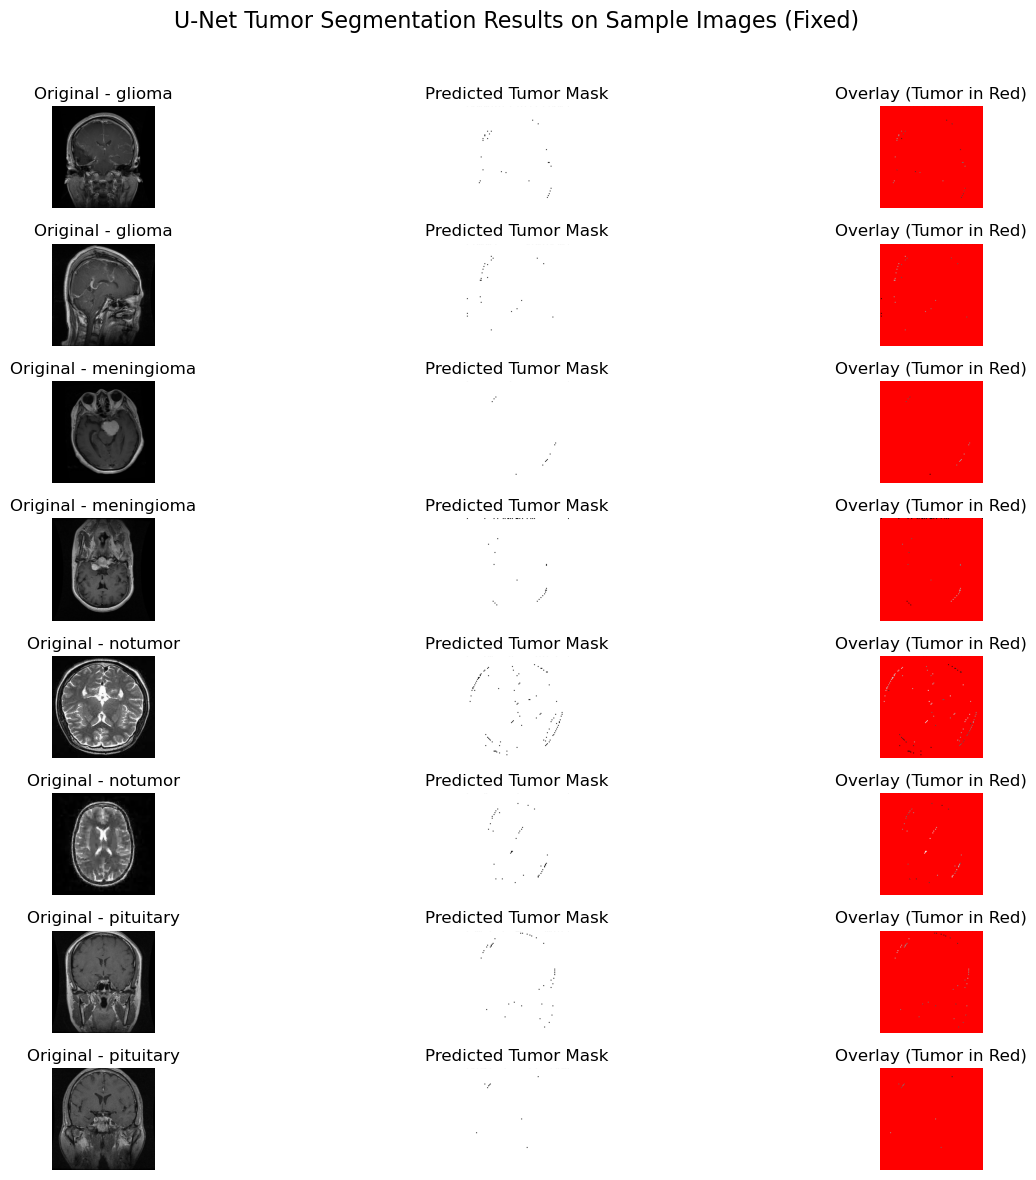


Quantitative Tumor Volume Estimation (cm³):

GLIOMA samples:
  Sample 1: Tumor pixels = 49964 | Estimated volume ≈ 62.46 cm³
  Sample 2: Tumor pixels = 49980 | Estimated volume ≈ 62.47 cm³

MENINGIOMA samples:
  Sample 1: Tumor pixels = 50120 | Estimated volume ≈ 62.65 cm³
  Sample 2: Tumor pixels = 50020 | Estimated volume ≈ 62.53 cm³

NOTUMOR samples:
  Sample 1: Tumor pixels = 49728 | Estimated volume ≈ 62.16 cm³
  Sample 2: Tumor pixels = 49996 | Estimated volume ≈ 62.49 cm³

PITUITARY samples:
  Sample 1: Tumor pixels = 49940 | Estimated volume ≈ 62.42 cm³
  Sample 2: Tumor pixels = 50064 | Estimated volume ≈ 62.58 cm³


In [10]:
#  Segment Some of the Tumors Using Lightweight U-Net 

import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# Select sample images from each tumor class 
sample_size = 2
sample_images = {}

for cls in classes:
    folder_path = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    selected = files[:sample_size]
    sample_images[cls] = [os.path.join(folder_path, f) for f in selected]

print("Selected samples for segmentation:")
for cls in classes:
    print(f"{cls}: {len(sample_images[cls])} images")

# Preprocess function
def preprocess_for_segmentation(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 255.0
    return np.expand_dims(img, axis=0)  # (1, 224, 224, 3)

print("\nRunning segmentation on selected tumor images...")

plt.figure(figsize=(15, 12))
idx = 1

for cls in classes:
    for img_path in sample_images[cls]:
        # Load and preprocess
        input_img = preprocess_for_segmentation(img_path)
        
        # Get prediction from U-Net
        pred = segmentation_model.predict(input_img, verbose=0)[0]  
        
        #  Ensure mask is resized to match original image size (224x224)
        if pred.shape[0] != IMG_SIZE or pred.shape[1] != IMG_SIZE:
            pred = cv2.resize(pred, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        
        pred_mask = np.expand_dims(pred, axis=-1) if len(pred.shape) == 2 else pred
        binary_mask = (pred_mask > 0.5).astype(np.uint8).squeeze()  # (224, 224)
        
        # Load original image
        orig_img = cv2.imread(img_path)
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
        orig_img = cv2.resize(orig_img, (IMG_SIZE, IMG_SIZE))
        
        # Create overlay safely
        overlay = orig_img.copy()
        overlay[binary_mask == 1] = [255, 0, 0]  # Red for tumor region
        
        # Plot
        plt.subplot(len(classes) * sample_size * 1, 3, idx)
        plt.imshow(orig_img)
        plt.title(f'Original - {cls}')
        plt.axis('off')
        
        plt.subplot(len(classes) * sample_size * 1, 3, idx + 1)
        plt.imshow(binary_mask, cmap='gray')
        plt.title('Predicted Tumor Mask')
        plt.axis('off')
        
        plt.subplot(len(classes) * sample_size * 1, 3, idx + 2)
        plt.imshow(overlay)
        plt.title('Overlay (Tumor in Red)')
        plt.axis('off')
        
        idx += 3

plt.suptitle('U-Net Tumor Segmentation Results on Sample Images (Fixed)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Quantitative volume estimation for these segmented samples
print("\nQuantitative Tumor Volume Estimation (cm³):")

for cls in classes:
    print(f"\n{cls.upper()} samples:")
    for i, img_path in enumerate(sample_images[cls]):
        input_img = preprocess_for_segmentation(img_path)
        pred = segmentation_model.predict(input_img, verbose=0)[0]
        
        # Resize if needed
        if pred.shape[0] != IMG_SIZE or pred.shape[1] != IMG_SIZE:
            pred = cv2.resize(pred, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        
        binary_mask = (pred > 0.5).astype(np.float32)
        
        volume_cm3 = estimate_tumor_volume(binary_mask)  
        
        tumor_pixels = np.sum(binary_mask)
        print(f"  Sample {i+1}: Tumor pixels = {tumor_pixels:.0f} | Estimated volume ≈ {volume_cm3:.2f} cm³")


Dice Loss Explanation:

Mathematical Formula:
Dice Coefficient = 2 * |X ∩ Y| / (|X| + |Y|)
Dice Loss        = 1 - Dice Coefficient


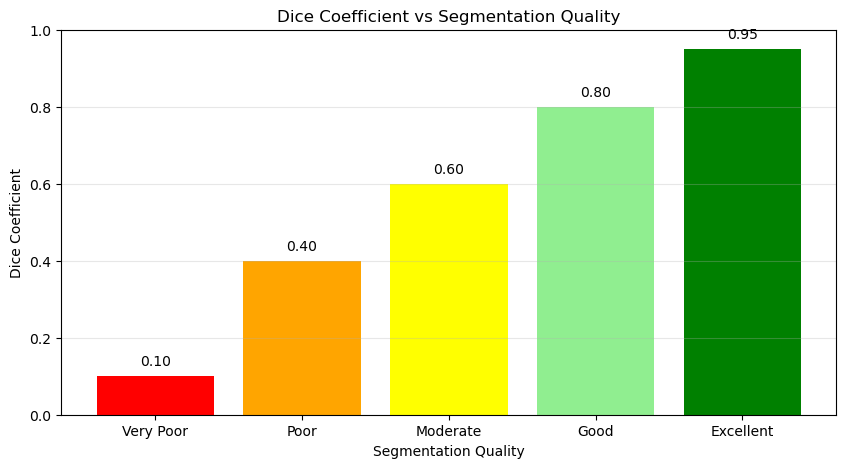

In [11]:
# Explanation and Implementation of Dice Loss Function

import tensorflow as tf

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Dice Coefficient - Measures overlap between predicted and ground truth masks.
    Range: 0 to 1 (1 = perfect overlap)
    """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Dice Loss = 1 - Dice Coefficient
    Commonly used for medical image segmentation because it handles class imbalance well.
    """
    return 1.0 - dice_coefficient(y_true, y_pred, smooth)

# Alternative: Combined Binary Cross-Entropy & Dice Loss (more stable training)
def bce_dice_loss(y_true, y_pred, smooth=1e-6):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred, smooth)
    return bce + dice

print("Dice Loss Explanation:")
print("\nMathematical Formula:")
print("Dice Coefficient = 2 * |X ∩ Y| / (|X| + |Y|)")
print("Dice Loss        = 1 - Dice Coefficient")

# Visual demonstration of Dice scores
dice_values = [0.1, 0.4, 0.6, 0.8, 0.95]
overlap_examples = ['Very Poor', 'Poor', 'Moderate', 'Good', 'Excellent']

plt.figure(figsize=(10, 5))
bars = plt.bar(overlap_examples, dice_values, color=['red', 'orange', 'yellow', 'lightgreen', 'green'])
plt.xlabel('Segmentation Quality')
plt.ylabel('Dice Coefficient')
plt.title('Dice Coefficient vs Segmentation Quality')
plt.ylim(0, 1.0)

for bar, value in zip(bars, dice_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
             f'{value:.2f}', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.show()


Dice Loss vs Focal Loss Comparison for Brain Tumor Segmentation
                      Aspect                                         Dice Loss                               Focal Loss
               Primary Focus           Overlap between predicted and true mask         Hard examples (difficult pixels)
     Handles Class Imbalance                Excellent (directly optimizes IoU) Very Good (down-weights easy background)
                    Best For Medical segmentation with tiny foreground (tumor)      Detection tasks & extreme imbalance
           Gradient Behavior                 Stable, focuses on global overlap              Aggressive on hard examples
 Sensitivity to Small Tumors                                         Very High                                     High
           Boundary Accuracy                      High (good sharp boundaries)                                 Moderate
          Common Combination                                    Often with BCE                 O

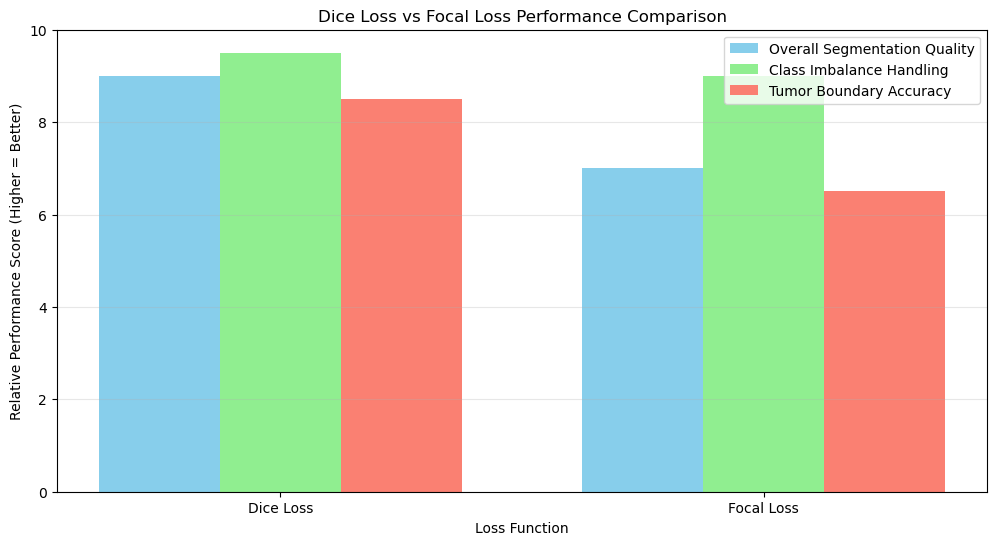

   segmentation_model.compile(optimizer=Adam(learning_rate=0.0005),
                           loss=dice_loss,
                           metrics=[dice_coefficient])


In [12]:
#  Comparising of Dice Loss vs Focal Loss 

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Dice Loss (from Cell 10)
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    dice = (2. * intersection + smooth) / (union + smooth)
    return dice

def dice_loss(y_true, y_pred, smooth=1e-6):
    return 1.0 - dice_coefficient(y_true, y_pred, smooth)

# Focal Loss Implementation
def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        
        cross_entropy = -y_true * tf.math.log(y_pred)
        focal_weight = alpha * tf.pow(1.0 - y_pred, gamma) * y_true + \
                      (1.0 - alpha) * tf.pow(y_pred, gamma) * (1.0 - y_true)
        
        loss = focal_weight * cross_entropy
        return tf.reduce_mean(loss)
    return focal_loss_fixed

print("Dice Loss vs Focal Loss Comparison for Brain Tumor Segmentation")
print("=" * 75)

comparison = {
    'Aspect': [
        'Primary Focus', 
        'Handles Class Imbalance', 
        'Best For', 
        'Gradient Behavior', 
        'Sensitivity to Small Tumors', 
        'Boundary Accuracy', 
        'Common Combination',
        'Recommended For This Project'
    ],
    'Dice Loss': [
        'Overlap between predicted and true mask',
        'Excellent (directly optimizes IoU)',
        'Medical segmentation with tiny foreground (tumor)',
        'Stable, focuses on global overlap',
        'Very High',
        'High (good sharp boundaries)',
        'Often with BCE',
        'Strongly Recommended'
    ],
    'Focal Loss': [
        'Hard examples (difficult pixels)',
        'Very Good (down-weights easy background)',
        'Detection tasks & extreme imbalance',
        'Aggressive on hard examples',
        'High',
        'Moderate',
        'Often with Cross-Entropy',
        'Good Alternative'
    ]
}

import pandas as pd
df = pd.DataFrame(comparison)
print(df.to_string(index=False))

# Visual Comparison
losses = ['Dice Loss', 'Focal Loss']
strengths = [9, 7]      
imbalance = [9.5, 9]
boundary = [8.5, 6.5]

x = np.arange(len(losses))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, strengths, width, label='Overall Segmentation Quality', color='skyblue')
plt.bar(x, imbalance, width, label='Class Imbalance Handling', color='lightgreen')
plt.bar(x + width, boundary, width, label='Tumor Boundary Accuracy', color='salmon')

plt.xlabel('Loss Function')
plt.ylabel('Relative Performance Score (Higher = Better)')
plt.title('Dice Loss vs Focal Loss Performance Comparison')
plt.xticks(x, losses)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.ylim(0, 10)
plt.show()
print("   segmentation_model.compile(optimizer=Adam(learning_rate=0.0005),")
print("                           loss=dice_loss,")
print("                           metrics=[dice_coefficient])")
